# Fraud Detection Baseline (Precision Metric)

이 노트북은 사기 거래 여부를 예측하는 기본 베이스라인입니다. 데이터톤이 처음이라면 `데이터 불러오기 -> 전처리 -> 파생변수 생성 -> 학습 -> 검증` 흐름을 먼저 익히는 용도로 보면 됩니다.

In [20]:
# 경고 메시지를 숨겨서 노트북 출력이 너무 지저분해지지 않게 합니다.
import warnings
# 실험 중 자주 뜨는 경고를 일단 감춥니다. 나중에 디버깅할 때는 다시 켜도 됩니다.
warnings.filterwarnings('ignore')

# 수치 계산용 라이브러리입니다.
import numpy as np
# 표 형태 데이터(DataFrame)를 다루는 핵심 라이브러리입니다.
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# 클래스 비율을 유지하면서 교차검증을 나누고, 하이퍼파라미터 탐색을 수행할 때 사용합니다.
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
# 이번 베이스라인의 평가 지표인 Precision 계산에 사용합니다.
from sklearn.metrics import precision_score, average_precision_score
# 문자열 범주형 변수를 숫자로 바꾸는 간단한 인코더입니다.
from sklearn.preprocessing import LabelEncoder

# 대회에서 자주 쓰이는 부스팅 모델 라이브러리입니다.
import lightgbm as lgb

# 데이터 불러오기

In [21]:
# 학습 데이터를 불러옵니다.
train = pd.read_csv("csv/train.csv")

# 맞혀야 하는 정답 컬럼 이름입니다.
TARGET = "fraud_bool"
# 각 행을 구분하는 식별자 컬럼입니다.
ID_COL = "id"

# EDA

In [22]:
pd.set_option("display.max_columns", None)
train.head()

,id,fraud_bool,yearly_income,name_email_sim,prev_addr_months,curr_addr_months,age_bucket,days_since_req,init_transfer_amt,payment_type,zip_req_count_4w,req_rate_6h,req_rate_24h,req_rate_4w,branch_req_count_8w,dob_email_count_4w,employment_status,credit_risk_score,is_free_email,housing_status,is_home_phone_valid,is_mobile_valid,bank_months_count,has_other_cards,req_credit_limit,is_foreign_req,application_source,session_length_min,device_os,is_session_persistent,device_email_cnt_8w,device_fraud_history,month_idx
0,0,0,0.8,0.996036,9,19,40,0.019167,-0.795951,AB,1260,7749.143962,6027.462430,6393.005946,11,12,CA,153,0,BC,0,1,1,1,510.0,0,INTERNET,4.125364,other,1,1,0,6
1,1,0,0.8,0.520470,12,10,30,0.010994,-0.667975,AD,3260,4195.365068,3217.379618,5480.920073,29,15,CB,283,1,BC,0,1,25,0,1500.0,0,INTERNET,8.147967,macintosh,0,1,0,4
2,2,0,0.5,0.792133,162,11,40,70.144985,-1.051204,AC,505,8933.154065,4556.265036,5017.372704,1,6,CA,140,1,BA,0,1,-1,0,200.0,0,INTERNET,4.996239,linux,1,1,0,3
3,3,0,0.1,0.846394,24,7,50,0.005721,-1.404540,AB,6032,4666.927400,3714.025815,4380.656607,710,5,CC,95,0,BB,1,1,31,0,200.0,0,INTERNET,5.860972,linux,1,1,0,6
4,4,0,0.9,0.232846,-1,81,40,0.023110,-0.519206,AD,1197,1647.657269,4806.205629,4898.316205,238,7,CA,86,1,BC,0,1,1,0,200.0,0,INTERNET,12.764765,windows,0,1,0,4


In [23]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 33 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     700000 non-null  int64  
 1   fraud_bool             700000 non-null  int64  
 2   yearly_income          700000 non-null  float64
 3   name_email_sim         700000 non-null  float64
 4   prev_addr_months       700000 non-null  int64  
 5   curr_addr_months       700000 non-null  int64  
 6   age_bucket             700000 non-null  int64  
 7   days_since_req         700000 non-null  float64
 8   init_transfer_amt      700000 non-null  float64
 9   payment_type           700000 non-null  object 
 10  zip_req_count_4w       700000 non-null  int64  
 11  req_rate_6h            700000 non-null  float64
 12  req_rate_24h           700000 non-null  float64
 13  req_rate_4w            700000 non-null  float64
 14  branch_req_count_8w    700000 non-nu

In [24]:
train

,id,fraud_bool,yearly_income,name_email_sim,prev_addr_months,curr_addr_months,age_bucket,days_since_req,init_transfer_amt,payment_type,zip_req_count_4w,req_rate_6h,req_rate_24h,req_rate_4w,branch_req_count_8w,dob_email_count_4w,employment_status,credit_risk_score,is_free_email,housing_status,is_home_phone_valid,is_mobile_valid,bank_months_count,has_other_cards,req_credit_limit,is_foreign_req,application_source,session_length_min,device_os,is_session_persistent,device_email_cnt_8w,device_fraud_history,month_idx
0,0,0,0.8,0.996036,9,19,40,0.019167,-0.795951,AB,1260,7749.143962,6027.462430,6393.005946,11,12,CA,153,0,BC,0,1,1,1,510.0,0,INTERNET,4.125364,other,1,1,0,6
1,1,0,0.8,0.520470,12,10,30,0.010994,-0.667975,AD,3260,4195.365068,3217.379618,5480.920073,29,15,CB,283,1,BC,0,1,25,0,1500.0,0,INTERNET,8.147967,macintosh,0,1,0,4
2,2,0,0.5,0.792133,162,11,40,70.144985,-1.051204,AC,505,8933.154065,4556.265036,5017.372704,1,6,CA,140,1,BA,0,1,-1,0,200.0,0,INTERNET,4.996239,linux,1,1,0,3
3,3,0,0.1,0.846394,24,7,50,0.005721,-1.404540,AB,6032,4666.927400,3714.025815,4380.656607,710,5,CC,95,0,BB,1,1,31,0,200.0,0,INTERNET,5.860972,linux,1,1,0,6
4,4,0,0.9,0.232846,-1,81,40,0.023110,-0.519206,AD,1197,1647.657269,4806.205629,4898.316205,238,7,CA,86,1,BC,0,1,1,0,200.0,0,INTERNET,12.764765,windows,0,1,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,699995,0,0.8,0.875161,-1,31,30,0.031370,-1.127735,AD,1099,6242.068820,5407.363861,4958.095930,14,14,CA,207,1,BC,0,1,28,1,500.0,0,INTERNET,8.902921,other,0,1,0,3
699996,699996,0,0.4,0.182020,-1,42,30,0.010726,48.546926,AA,1409,5148.673710,6451.903670,3093.683723,19,19,CA,98,0,BC,1,1,1,1,200.0,0,INTERNET,2.481963,other,1,1,0,5
699997,699997,0,0.9,0.186917,30,8,30,0.037580,32.035649,AA,742,2339.270398,3594.662171,5202.846791,620,8,CA,134,1,BC,0,1,21,0,200.0,0,INTERNET,7.066818,linux,0,1,0,2
699998,699998,0,0.7,0.758478,30,2,30,0.006646,-0.916600,AC,961,5523.852621,4351.831058,5536.708151,0,22,CA,95,1,BC,0,1,-1,0,200.0,0,INTERNET,2.727112,linux,0,1,0,1


In [25]:
train['fraud_bool'].value_counts(normalize=True)

fraud_bool
0    0.989083
1    0.010917
Name: proportion, dtype: float64

In [26]:
train.set_index(ID_COL, inplace=True)

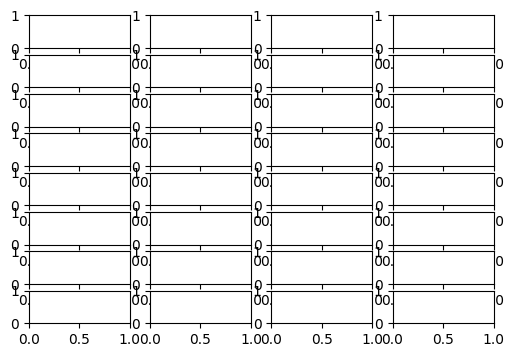

In [27]:
fig, ax = plt.subplots(figsize=(6, 4), ncols=4, nrows=8)



In [28]:
fraud_ratio = train['fraud_bool'].mean()
imbalance_ratio = (train['fraud_bool'] == 0).sum() / (train['fraud_bool'] == 1).sum()

print(f"Fraud ratio: {fraud_ratio:.4f}")
print(f"Imbalance ratio (non-fraud : fraud): {imbalance_ratio:.2f}")

Fraud ratio: 0.0109
Imbalance ratio (non-fraud : fraud): 90.60


In [29]:
# 숫자형 컬럼 목록을 추출합니다.
num_cols = train.select_dtypes(include=["int64","float64"]).columns.tolist()
# 범주형 컬럼 목록을 추출합니다.
cat_cols = train.select_dtypes(include=["object"]).columns.tolist()
# boolean 컬럼 목록을 추출합니다, 0 또는 1로만 이루어진 컬럼을 추출합니다.
bool_cols = [col for col in train.columns if train[col].dropna().isin([0, 1]).all()]

# 숫자형 컬럼 목록에서 boolean 컬럼을 제거합니다.
num_cols = [col for col in num_cols if col not in bool_cols]

# 정답 컬럼과 ID 컬럼은 특징(feature) 목록에서 빼줍니다.
for col in [TARGET, ID_COL]:
    # 숫자형 목록에 들어있다면 제거합니다.
    if col in num_cols:
        num_cols.remove(col)

In [30]:
def fraud_rate_by_category(train, col):
    result = train.groupby(col)['fraud_bool'].mean().sort_values(ascending=False)
    return result

for col in cat_cols:
    print(fraud_rate_by_category(train, col))
    print("-" * 40)


payment_type
AC    0.016745
AB    0.011131
AD    0.010595
AA    0.005089
AE    0.004854
Name: fraud_bool, dtype: float64
----------------------------------------
employment_status
CC    0.025477
CG    0.012821
CA    0.011990
CB    0.006893
CD    0.003732
CE    0.002342
CF    0.001950
Name: fraud_bool, dtype: float64
----------------------------------------
housing_status
BA    0.036954
BD    0.008571
BC    0.006169
BB    0.005954
BG    0.005682
BF    0.004314
BE    0.003338
Name: fraud_bool, dtype: float64
----------------------------------------
application_source
TELEAPP     0.015010
INTERNET    0.010888
Name: fraud_bool, dtype: float64
----------------------------------------
device_os
windows      0.024500
macintosh    0.013592
x11          0.011370
other        0.005765
linux        0.005070
Name: fraud_bool, dtype: float64
----------------------------------------


결제 타입 AC
취업 상태 CC
주거 상태 BA => 다른 타입에 비해 높음
application_source => 두 타입이 비슷함
device_os => windows가 다른 타입에 비해 2배 정도 높음


양의 관계
yearly_income
age_bucket
credit_risk_score
req_credit_limit

음의 관계
name_email_sim
prev_addr_months
dob_email_count_4w

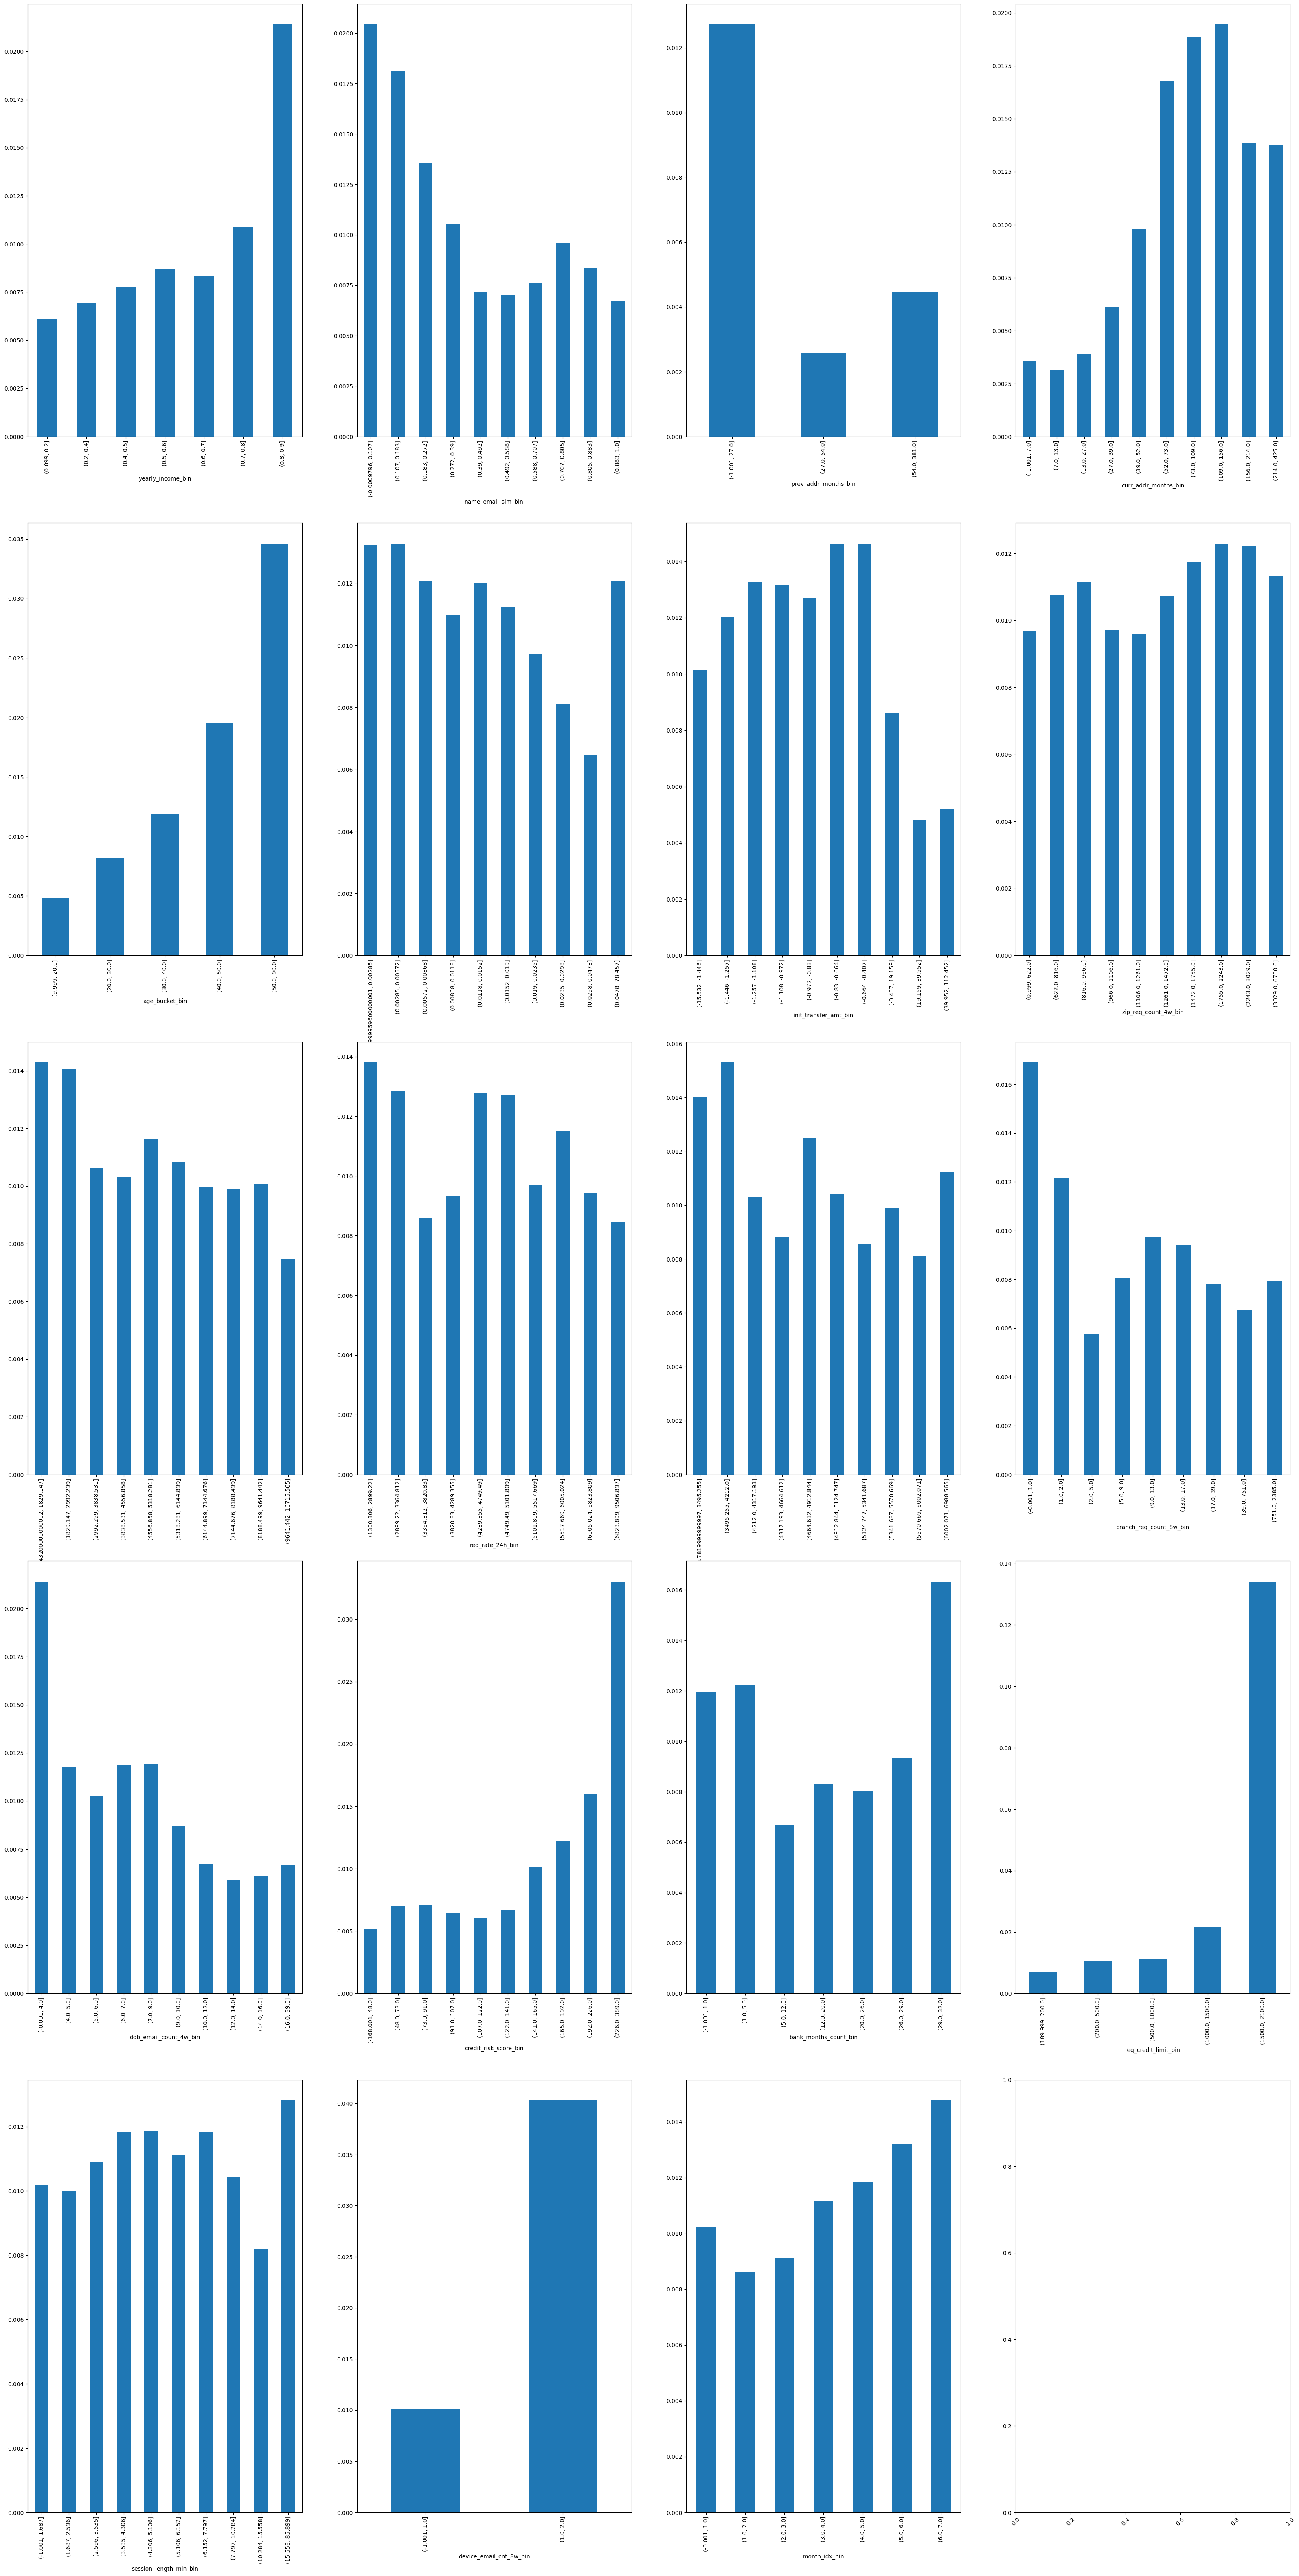

In [31]:
# train['income_bin'] = pd.qcut(train['yearly_income'], 10, duplicates='drop')
fig, ax = plt.subplots(figsize=(40, 80), ncols=4, nrows=5)
_df = train.copy()
for col in num_cols:
    
    _df[col + '_bin'] = pd.qcut(_df[col], 10, duplicates='drop')
    fraud_rate = _df.groupby(col+'_bin')['fraud_bool'].mean()
    fraud_rate.plot(kind='bar', ax=ax.flatten()[num_cols.index(col)])
    plt.xticks(rotation=45)

In [32]:
fraud_rate = train.groupby('device_email_cnt_8w')['fraud_bool'].mean()
print(fraud_rate)

device_email_cnt_8w
-1    0.007937
 0    0.022815
 1    0.010073
 2    0.040280
Name: fraud_bool, dtype: float64


1. is_free_email - 1
2. home_phone_valid - 0
3. is_mobile_valid - 0
4. has other cards - 0
5. is_foreign_req - 1
6. is_session_persistent - 0

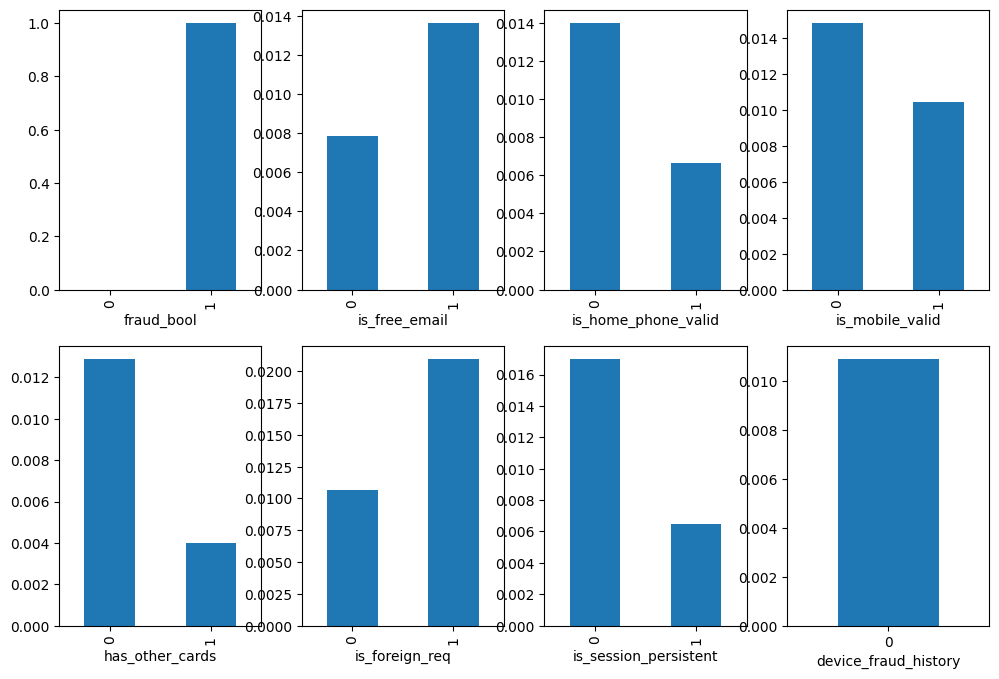

In [33]:
# 불리언 컬럼 별 사기 비율을 막대그래프로 나타냅니다.
fig, ax = plt.subplots(figsize=(12, 8), ncols=4, nrows=2)
for col in bool_cols:
    fraud_rate = train.groupby(col)['fraud_bool'].mean()
    fraud_rate.plot(kind='bar', ax=ax.flatten()[bool_cols.index(col)])
    plt.xticks(rotation=0)

## columns.md 기반으로 해볼 만한 추가 아이디어

### EDA 아이디어
- 현재 `train.info()` 기준으로 결측치는 전체 데이터에서 없으므로, 이번 EDA의 초점은 결측치 처리보다 `타깃과의 관계`, `이상치`, `분포 차이` 확인에 두는 것이 좋습니다.
- `fraud_bool` 비율을 먼저 확인해서 클래스 불균형 정도를 파악합니다. 이후 precision만 볼지, recall과 함께 볼지 판단하는 기준이 됩니다.
- `yearly_income`, `credit_risk_score`, `req_credit_limit`, `init_transfer_amt`, `session_length_min`은 사기/정상별 분포 비교를 해볼 만합니다. 박스플롯이나 구간화 후 타깃 평균을 보면 어느 구간에서 사기가 몰리는지 보입니다.
- `req_rate_6h`, `req_rate_24h`, `req_rate_4w`, `zip_req_count_4w`, `branch_req_count_8w`, `dob_email_count_4w`, `device_email_cnt_8w`는 '짧은 기간에 신청이 몰리는가'를 보는 핵심 변수입니다. 로그 스케일 히스토그램이나 분위수 테이블로 긴 꼬리 분포를 확인해볼 만합니다.
- `name_email_sim`, `is_free_email`, `device_fraud_history`, `is_foreign_req`, `is_home_phone_valid`, `is_mobile_valid`, `is_session_persistent`는 범주별 사기 비율을 바로 계산해보면 좋습니다. 특히 단일 변수만으로도 precision이 잘 나오는 패턴이 있을 수 있습니다.
- `application_source`, `device_os`, `payment_type`, `employment_status`, `housing_status`, `age_bucket`, `month_idx`는 카테고리별 fraud rate를 정렬해서 보면 의미 있는 구간을 찾기 쉽습니다.
- `curr_addr_months`, `prev_addr_months`, `bank_months_count`, `days_since_req`는 체류/계정 유지 기간 관련 변수이므로 매우 짧거나 음수/이상값처럼 보이는 값이 있는지 먼저 확인하는 것이 좋습니다. `train.head()`에서 이미 `bank_months_count=-1` 같은 값이 보여서, 실제로는 '없음' 또는 특수값일 가능성을 의심해볼 만합니다.
- 상관관계는 전체 Pearson보다 `fraud_bool=1` 집단과 `fraud_bool=0` 집단에서 각각 어떤 조합이 다르게 움직이는지 보는 것이 더 유용할 수 있습니다. 특히 신청량 계열(`req_rate_*`)은 서로 강하게 연관될 가능성이 큽니다.

### Feature Engineering 아이디어
- `req_rate_6h / req_rate_24h`, `req_rate_24h / req_rate_4w`처럼 단기 대비 장기 신청량 비율을 더 만들어볼 수 있습니다. 평소보다 갑자기 몰린 요청인지 잡는 데 도움이 됩니다.
- `zip_req_count_4w / branch_req_count_8w`, `device_email_cnt_8w / dob_email_count_4w`처럼 지역/지점/기기/신원 단위의 밀집도를 비교하는 비율 변수를 만들 수 있습니다.
- `req_credit_limit / yearly_income`, `init_transfer_amt / req_credit_limit`처럼 소득 대비 요청 한도, 요청 한도 대비 최초 이체금 비율을 만들면 과도한 신청 패턴을 포착할 수 있습니다.
- `curr_addr_months - prev_addr_months`, `curr_addr_months / (bank_months_count + 1)`, `bank_months_count - days_since_req`처럼 거주 안정성과 금융 활동 이력을 섞은 변수를 시도해볼 수 있습니다.
- `is_free_email * name_email_sim`, `device_fraud_history * is_foreign_req`, `is_mobile_valid * is_home_phone_valid`처럼 이진 변수 간 상호작용도 간단하지만 효과가 있을 수 있습니다.
- `application_source`와 `device_os`, `payment_type`와 `housing_status`, `employment_status`와 `yearly_income`처럼 범주형 조합을 문자열로 합쳐 새 범주형 변수로 만드는 것도 시도해볼 만합니다.
- `age_bucket`, `credit_risk_score`, `yearly_income`, `session_length_min`은 구간화(bin)한 뒤 범주형으로 넣어보는 방법도 있습니다. LightGBM은 원래 연속형을 잘 다루지만, 비선형 구간 효과가 강하면 도움이 될 수 있습니다.
- `month_idx`는 익명화된 월 정보지만 시계열 순서가 있을 가능성이 있으므로, 월별 fraud rate 차이가 크다면 time split 검증도 고려할 만합니다.
- `bank_months_count == -1` 같은 특수값이 실제로 존재한다면, 단순 수치로 쓰는 것보다 `is_bank_history_missing_like` 같은 indicator 변수를 추가하는 편이 더 안정적일 수 있습니다.


1. is_free_email - 1
2. home_phone_valid - 0
3. is_mobile_valid - 0
4. has other cards - 0
5. is_foreign_req - 1
6. is_session_persistent - 0

### 우선순위 추천
1. 신청량/밀집도 계열 비율 변수 확장
2. 금액/소득/한도 비율 변수 추가
3. 특수값 indicator 추가 (`bank_months_count`, 기간 변수들)
4. 범주형 조합 변수 2~3개 실험
5. threshold 0.5 고정 대신 OOF 기준 precision 최대 threshold 탐색

# Preprocessing

# Feature Engineering

In [34]:
# 원본 데이터를 보존하기 위해 복사본에서 작업합니다.
df = train.copy()

# 6시간 요청량이 24시간 요청량 대비 얼마나 높은지 비율 특징을 만듭니다.
df["req_rate_ratio_6h_24h"] = df["req_rate_6h"]/(df["req_rate_24h"]+1e-5)
# 현재 주소 거주 기간이 이전 주소 거주 기간 대비 얼마나 안정적인지 보는 특징입니다.
df["addr_stability"] = df["curr_addr_months"]/(df["prev_addr_months"]+1)
# 의미 없는 device_fraud_history는 제거합니다.
df.drop(columns=['device_fraud_history'], inplace=True)

risky_bool_dict = {
    'is_free_email': 1,
    'is_home_phone_valid': 0,
    'is_mobile_valid': 0,
    'has_other_cards': 0,
    'is_foreign_req': 1,
    'is_session_persistent': 0
}

df['credit_risk_score_2'] = 0

for col in risky_bool_dict.keys():
    df['credit_risk_score_2'] = df['credit_risk_score_2'] + (df[col] == risky_bool_dict[col]).astype(int) 



# LightGBM에 바로 넣기 위해 범주형 컬럼을 숫자로 변환합니다.
for col in cat_cols:
    # 컬럼마다 별도의 인코더를 학습합니다.
    le = LabelEncoder()
    # 결측치 가능성까지 고려해 문자열로 바꾼 뒤 정수 라벨로 변환합니다.
    df[col] = le.fit_transform(df[col].astype(str)) # type: ignore

In [35]:
# 학습에 사용할 feature 목록을 정의합니다.
FEATURES = [col for col in df.columns if col not in [TARGET, ID_COL]]

# 입력 변수 X를 만듭니다.
X = df[FEATURES]
# 정답 벡터 y를 만듭니다.
y = df[TARGET]

# Validation Method & Train

In [36]:
# 재현 가능성을 위해 random_state를 고정합니다.
RANDOM_STATE = 42
# 탐색 횟수는 계산량과 성능 사이 균형을 고려해 36회로 둡니다.
RANDOM_SEARCH_N_ITER = 36

# 최종 평가는 5-fold stratified CV 기준으로 맞춥니다.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# EarlyStoppingLGBMClassifier 실험은 성능 저하가 확인되어 비활성화합니다.
# class LGBMEarlyStoppingClassifier(BaseEstimator, ClassifierMixin):
#     ...

# RandomizedSearchCV와 최종 학습에서 공통으로 쓸 LightGBM 파라미터를 조합합니다.
def build_model_params(search_params):
    return {
        **search_params,
        "objective": "binary",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": -1,
    }

# 동일한 5-fold 기준으로 OOF AP를 계산하는 헬퍼입니다.
def compute_oof_predictions(model_params, X, y, cv):
    preds = np.zeros(len(X))
    fold_scores = []
    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), 1):
        print(f"Fold {fold}")
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        model = lgb.LGBMClassifier(**build_model_params(model_params))
        model.fit(X_train, y_train)
        valid_pred = model.predict_proba(X_valid)[:, 1]
        preds[valid_idx] = valid_pred
        fold_ap = average_precision_score(y_valid, valid_pred)
        fold_scores.append(fold_ap)
        print("Average Precision:", fold_ap)
    return preds, fold_scores

# 탐색 공간은 너무 넓지 않게 줄이되, 성능에 영향이 큰 축은 유지합니다.
param_distributions = {
    "n_estimators": [100, 200, 300, 500, 700],
    "learning_rate": [0.02, 0.03, 0.05, 0.07, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 4, 6, 8, 10],
    "min_child_samples": [20, 50, 100, 200],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.01, 0.1, 0.5],
    "reg_lambda": [0.0, 0.01, 0.1, 0.5, 1.0],
    "min_split_gain": [0.0, 0.01, 0.05, 0.1],
}

# 순정 LGBMClassifier를 RandomizedSearchCV에 직접 넣습니다.
base_model = lgb.LGBMClassifier(
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)


In [37]:
# 순정 LGBMClassifier 기준으로 단일 RandomizedSearchCV를 수행합니다.
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=RANDOM_SEARCH_N_ITER,
    scoring="average_precision",
    cv=skf,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
random_search.fit(X, y)

# 탐색 결과 중 가장 성능이 좋았던 파라미터를 저장합니다.
best_params = random_search.best_params_
best_cv_score = random_search.best_score_

print("Best CV Average Precision:", best_cv_score)
print("Best Params:", best_params)

# 선택된 파라미터로 OOF(out-of-fold) 예측값을 다시 계산합니다.
oof_preds, fold_scores = compute_oof_predictions(best_params, X, y, skf)
final_oof_ap = average_precision_score(y, oof_preds)

# 제출 전 비교 가능한 형태로 실험 요약을 남깁니다.
experiment_summary = {
    "search_n_iter": RANDOM_SEARCH_N_ITER,
    "cv_folds": 5,
    "best_cv_score": float(best_cv_score),
    "fold_scores": [float(score) for score in fold_scores],
    "final_oof_ap": float(final_oof_ap),
    "best_params": best_params,
}


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best CV Average Precision: 0.1725079610029104
Best Params: {'subsample': 1.0, 'reg_lambda': 0.0, 'reg_alpha': 0.5, 'num_leaves': 15, 'n_estimators': 700, 'min_split_gain': 0.05, 'min_child_samples': 200, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Fold 1
Average Precision: 0.16963598013152975
Fold 2
Average Precision: 0.1802778773438477
Fold 3
Average Precision: 0.180759574360755
Fold 4
Average Precision: 0.16619486256382734
Fold 5
Average Precision: 0.16567151061459234


# 검증

In [38]:
# 단일 RandomizedSearchCV 기준의 최종 검증 성능을 확인합니다.
print("Best CV Average Precision:", best_cv_score)
print("Final OOF Average Precision:", final_oof_ap)
print(experiment_summary)

Best CV Average Precision: 0.1725079610029104
Final OOF Average Precision: 0.17143690811574014
{'search_n_iter': 36, 'cv_folds': 5, 'best_cv_score': 0.1725079610029104, 'fold_scores': [0.16963598013152975, 0.1802778773438477, 0.180759574360755, 0.16619486256382734, 0.16567151061459234], 'final_oof_ap': 0.17143690811574014, 'best_params': {'subsample': 1.0, 'reg_lambda': 0.0, 'reg_alpha': 0.5, 'num_leaves': 15, 'n_estimators': 700, 'min_split_gain': 0.05, 'min_child_samples': 200, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 0.7}}


In [39]:
# Kaggle 제출용 테스트 데이터를 불러옵니다.
test = pd.read_csv("csv/test.csv")

# train / test에 동일한 feature engineering을 적용하기 위해 각각 복사본을 만듭니다.
train_sub = train.copy()
test_sub = test.copy()

# 학습 데이터와 같은 파생변수를 테스트 데이터에도 동일하게 생성합니다.
for frame in [train_sub, test_sub]:
    frame["req_rate_ratio_6h_24h"] = frame["req_rate_6h"] / (frame["req_rate_24h"] + 1e-5)
    frame["addr_stability"] = frame["curr_addr_months"] / (frame["prev_addr_months"] + 1)
    frame.drop(columns=['device_fraud_history'], inplace=True)
    risky_bool_dict = {
        'is_free_email': 1,
        'is_home_phone_valid': 0,
        'is_mobile_valid': 0,
        'has_other_cards': 0,
        'is_foreign_req': 1,
        'is_session_persistent': 0
    }
    frame['credit_risk_score_2'] = 0
    for col in risky_bool_dict.keys():
        frame['credit_risk_score_2'] = frame['credit_risk_score_2'] + (frame[col] == risky_bool_dict[col]).astype(int) 

# 범주형 인코딩을 train / test 전체 기준으로 맞추기 위해 합쳐서 처리합니다.
full = pd.concat([train_sub.drop(columns=[TARGET]), test_sub], axis=0, ignore_index=True)
cat_cols_sub = full.select_dtypes(include=["object"]).columns.tolist()

# 컬럼별로 동일한 라벨 인코딩 규칙을 적용합니다.
for col in cat_cols_sub:
    le = LabelEncoder()
    full[col] = le.fit_transform(full[col].astype(str)) # type: ignore

# 다시 train / test로 분리합니다.
X_train_full = full.iloc[:len(train_sub)].copy()
X_test = full.iloc[len(train_sub):].copy()
y_train_full = train_sub[TARGET].copy()

# ID 컬럼은 학습 feature에서 제외합니다.
submit_features = [col for col in X_train_full.columns if col != ID_COL]

# 전체 학습 데이터로 순정 LightGBM 최종 모델을 다시 학습합니다.
final_model = lgb.LGBMClassifier(**build_model_params(best_params))
final_model.fit(X_train_full[submit_features], y_train_full)

# 테스트 데이터의 사기 확률을 예측합니다.
test_pred = final_model.predict_proba(X_test[submit_features])[:, 1] # type: ignore

# 제출 파일은 id와 fraud 두 컬럼으로 저장합니다.
submission = pd.DataFrame({
    "id": test[ID_COL],
    "fraud": test_pred
})

# Kaggle에 바로 업로드할 수 있도록 CSV로 저장합니다.
submission.to_csv("submission_baseline.csv", index=False)

# 저장 결과를 확인합니다.
print(submission.head())
print("Saved to submission_baseline.csv")

   id     fraud
0   0  0.004197
1   1  0.019330
2   2  0.005009
3   3  0.000568
4   4  0.007749
Saved to submission_baseline.csv
